In this next section, I will work on Geospatial visualisation and various other forms of visualisation.

In [ ]:
from pyspark.sql import SparkSession

# Initialise Spark session
spark = (
    SparkSession.builder.appName("Rideshare_Analysis")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)


In [ ]:
# When session restarts, continue progress from here
from pyspark.sql.types import *
from pyspark.ml.linalg import VectorUDT

# Define the schema
schema = StructType([
    StructField("hvfhs_license_num", StringType(), True),
    StructField("pickup_datetime", TimestampType(), True),
    StructField("PULocationID", IntegerType(), True),
    StructField("trip_miles", DoubleType(), True),
    StructField("trip_time", LongType(), True),
    StructField("license_vec", VectorUDT(), True),
    StructField("day_of_week", IntegerType(), True),
    StructField("hour_of_day", IntegerType(), True),
    StructField("month", IntegerType(), True),
    StructField("day_vec", VectorUDT(), True),
    StructField("hour_vec", VectorUDT(), True),
    StructField("PULocation_vec", VectorUDT(), True),
    StructField("trip_miles_standardised", DoubleType(), True),
    StructField("earnings_per_hour", DoubleType(), True),
    StructField("feelslike", DoubleType(), True),
    StructField("precip", DoubleType(), True),
    StructField("preciptype", StringType(), True),
    StructField("feelslike_standardised", DoubleType(), True),
    StructField("precip_standardised", DoubleType(), True),
    StructField("preciptype_index", DoubleType(), True),
    StructField("preciptype_vec", VectorUDT(), True),
    StructField("is_public_holiday", IntegerType(), True)
])

# Load the Parquet file with the defined schema
final_df = spark.read.schema(schema).parquet("../data/curated/chunk_*.parquet")


In [ ]:
import pandas as pd
import geopandas as gpd

# Loading shapefile and taxi zone data
sf = gpd.read_file("../data/raw_csv/taxi_zones/taxi_zones.shp")
zones = pd.read_csv("../data/raw_csv/taxi_zone_lookup.csv")

# Preview
sf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [ ]:
# Convert geometry shape to latitude and longitude
# Attributed to Tutorial 2 MAST30034
sf['geometry'] = sf['geometry'].to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")

# Preview
sf.head()

In [ ]:
# Merge shapefile with zones
gdf= gpd.GeoDataFrame(pd.merge(zones, sf, on='LocationID', how='inner'))
gdf.head()

,LocationID,Borough,Zone,service_zone,OBJECTID,Shape_Leng,Shape_Area,zone,borough,geometry
0,1,EWR,Newark Airport,EWR,1,0.116357,0.000782,Newark Airport,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,Queens,Jamaica Bay,Boro Zone,2,0.433470,0.004866,Jamaica Bay,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone,3,0.084341,0.000314,Allerton/Pelham Gardens,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,Manhattan,Alphabet City,Yellow Zone,4,0.043567,0.000112,Alphabet City,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,Staten Island,Arden Heights,Boro Zone,5,0.092146,0.000498,Arden Heights,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [ ]:
# Create GeoJson object
geoJSON = gdf[['LocationID', 'geometry']].drop_duplicates('LocationID').to_json()

In [ ]:
import folium, numpy as np

# Prepare sample data for geospatial visualisation
# Select only columns needed to reduce load on pandas
sample_df = final_df.select(['PULocationID', 'earnings_per_hour'])

# Hopefully help to speed up pandas conversion later
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

# Only use 1% of the data for visualisation and convert to Pandas
sample_df_pd = sample_df.sample(0.05, seed=42).toPandas()

# Merge with gdf, geometric information
sample_df_pd = sample_df_pd.merge(gdf[['LocationID', 'geometry']], left_on='PULocationID', right_on='LocationID').drop('LocationID', axis=1)

# Query, Group by PULocationID, calculate the average earnings per hour within those groups
average_earnings = sample_df_pd[['PULocationID', 'earnings_per_hour']].groupby('PULocationID').agg({
    'earnings_per_hour': 'mean'
}).rename({'earnings_per_hour': 'avg_earnings_per_hour'}, axis=1)

# Create a log column for avg earnings
average_earnings['log_avg_earnings_per_hour'] = np.log1p(average_earnings['avg_earnings_per_hour'])

In [ ]:
# Initialise map with similar coordinates to the tutorial
m = folium.Map(location=[40.73, -73.74], tiles="OpenStreetMap", zoom_start=10)

# Initialise the Choropleth layer
c = folium.Choropleth(
    geo_data=geoJSON,
    name='choropleth',
    data=average_earnings.reset_index(),
    columns=['PULocationID', 'log_avg_earnings_per_hour'], 
    key_on='properties.LocationID', 
    fill_color='YlOrRd',  
    nan_fill_color='black',
    legend_name='Log Average Earnings per Hour (USD$)' 
)

# Add the Choropleth layer to the map
c.add_to(m)

In [ ]:
# Add markers
# Merge gdf with average_earnings to get both geometry and earnings data
gdf_merged = gdf.merge(average_earnings, left_on='LocationID', right_on='PULocationID', how='inner')

# Sort by highest log_average_earnings per hour.
top_3 = gdf_merged.sort_values(by = 'log_avg_earnings_per_hour', ascending=False).head(3)

# Get centroids for these top 3
top_3['centroid'] = top_3['geometry'].apply(lambda x: (x.centroid.y, x.centroid.x))

# Iterate to add marker
for zone_name, coord, earnings in top_3[['Zone', 'centroid', 'log_avg_earnings_per_hour']].values:
    m.add_child(
        folium.Marker(location=coord, popup = f"{zone_name} -> Log Average Earnings: {earnings:.2f}")
    )


# Save the map to plots folder
m.save('../plots/log_average_earnings_per_hour_map.html')

# Display map
m

In [ ]:
# Group by PULocationID, calculate the demand (trip_count) within those groups
demand = sample_df_pd[['PULocationID']].groupby('PULocationID').agg({
    'PULocationID': 'count'
}).rename({'PULocationID': 'trip_count'}, axis=1)

# Initialise map with similar coordinates to the tutorial
m = folium.Map(location=[40.73, -73.74], tiles="OpenStreetMap", zoom_start=10)

# Initialise the Choropleth layer
c = folium.Choropleth(
    geo_data=geoJSON,
    name='choropleth',
    data=demand.reset_index(),
    columns=['PULocationID', 'trip_count'], 
    key_on='properties.LocationID', 
    fill_color='YlOrRd',  
    nan_fill_color='black',
    legend_name='Trip Count (Demand)' 
)

# Add the Choropleth layer to the map
c.add_to(m)

# Save the map to plots folder
m.save('../plots/trip_count_demand_map.html')

# Display map
m


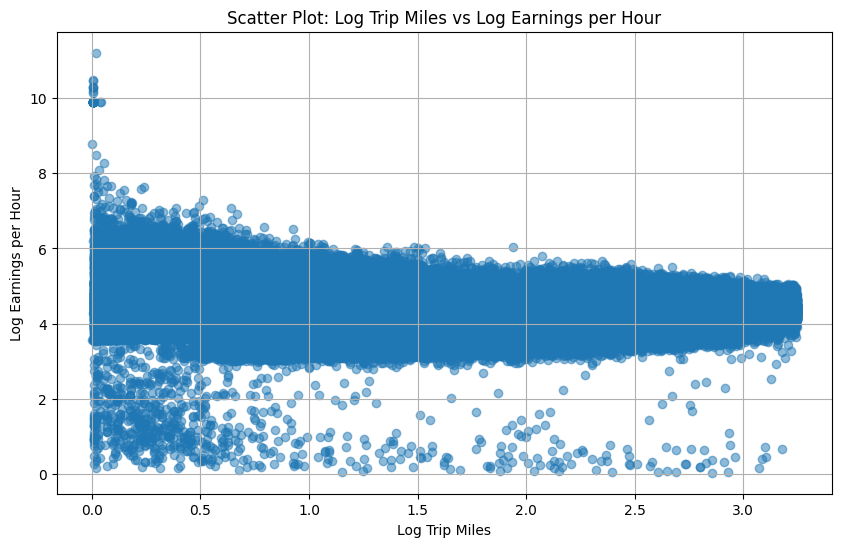

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select only columns needed to reduce load on pandas
sample_df = final_df.select(['trip_miles', 'earnings_per_hour'])

# Hopefully help to speed up pandas conversion later
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

# Only use 0.1% of the data for visualisation and convert to Pandas
sample_df_pd = sample_df.sample(0.05, seed=42).toPandas()


# Apply log transformations to trip_miles, earnings_per_hour
sample_df_pd['log_trip_miles'] = np.log1p(sample_df_pd['trip_miles'])
sample_df_pd['log_earnings_per_hour'] = np.log1p(sample_df_pd['earnings_per_hour'])

# Scatter plot between log_trip_miles and log_earnings_per_hour
plt.figure(figsize = (10, 6))
plt.scatter(sample_df_pd['log_trip_miles'], sample_df_pd['log_earnings_per_hour'], alpha=0.5)
plt.title('Scatter Plot: Log Trip Miles vs Log Earnings per Hour')
plt.xlabel('Log Trip Miles')
plt.ylabel('Log Earnings per Hour')
plt.grid(True)

# Show the plot
plt.show()





In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Select only columns needed to reduce load on pandas
sample_df = final_df.select(['hvfhs_license_num', 'earnings_per_hour'])

# Hopefully help to speed up pandas conversion later
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

# Only use 5% of the data for visualisation and convert to Pandas
sample_df_pd = sample_df.sample(0.05, seed=42).toPandas()

# Filter the dataset for Uber and Lyft
uber_df = sample_df_pd[sample_df_pd['hvfhs_license_num'] == 'HV0003']
lyft_df = sample_df_pd[sample_df_pd['hvfhs_license_num'] == 'HV0005']

# Combine both for plotting
combined_df = pd.concat([uber_df.assign(service='Uber'), lyft_df.assign(service='Lyft')])

# Apply log transformation
combined_df['log_earnings_per_hour'] = np.log1p(combined_df['earnings_per_hour'])

# Initialise the plot
plt.figure(figsize=(12, 6))

# Create boxplot
sns.boxplot(x='service', y='log_earnings_per_hour', data=combined_df, palette="Set3")

# Title and labels
plt.title('Boxplot: Earnings per Hour by Service (Uber vs Lyft)')
plt.xlabel('Service')
plt.ylabel('Log Earnings per Hour (USD)')

# Save the plot to a plots folder
plt.savefig('../plots/Earnings per Hour by Service (Uber vs Lyft).png')

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only columns needed to reduce load on pandas
sample_df = final_df.select(['hour_of_day', 'day_of_week', 'earnings_per_hour'])

# Hopefully help to speed up pandas conversion later
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

# Only use 1% of the data for visualisation and convert to Pandas
sample_df_pd = sample_df.sample(0.01, seed=42).toPandas()  

# Group by hour of day and day of week to calculate the average earnings per hour
hourly_earnings = sample_df_pd.groupby(['hour_of_day', 'day_of_week'])['earnings_per_hour'].mean().reset_index()

# Pivot the data so that days of the week are columns
hourly_earnings_pivot = hourly_earnings.pivot(index='hour_of_day', columns='day_of_week', values='earnings_per_hour')

# Reorder the columns to ensure the days are in the correct order
day_order = [1, 2, 3, 4, 5, 6, 7]
hourly_earnings_pivot = hourly_earnings_pivot[day_order]


In [ ]:
# Set the plot size
plt.figure(figsize=(14, 8))

# Plot each day's earnings per hour
for day in day_order:
    plt.plot(hourly_earnings_pivot.index, hourly_earnings_pivot[day], label=day)

# Adding labels and title
plt.title('Average Earnings per Hour by Hour of Day (for each Day of the Week)')
plt.xlabel('Hour of Day')
plt.ylabel('Earnings per Hour (USD)')
plt.legend(title='Day of the Week', labels=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
plt.grid(True)

# Save the plot to a plots folder
plt.savefig('../plots/average_earnings_per_hour_by_hour_of_day.png')

plt.show()